In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
names = ["Name","MJD","Phase (days)","Filter","Magnitude","Magnitude Error","Flux","Flux Error"]
SweetSpot = pd.read_csv("https://content.cld.iop.org/journals/1538-3881/155/5/201/revision1/ajaab901t8_mrt.txt", 
                            sep="\\s+", skiprows=25, header = None, names = names)
SweetSpot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186 entries, 0 to 185
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             186 non-null    object 
 1   MJD              186 non-null    float64
 2   Phase (days)     186 non-null    float64
 3   Filter           186 non-null    object 
 4   Magnitude        186 non-null    float64
 5   Magnitude Error  186 non-null    float64
 6   Flux             186 non-null    float64
 7   Flux Error       186 non-null    float64
dtypes: float64(6), object(2)
memory usage: 11.8+ KB


In [3]:
SweetSpot.head()

,Name,MJD,Phase (days),Filter,Magnitude,Magnitude Error,Flux,Flux Error
0,CSS121009:011101-172841,56234.27359,14.27359,WHIRCJ,18.97756,0.05157,256.4340,12.1698
1,CSS121009:011101-172841,56229.31361,9.31361,WHIRCH,18.64361,0.04781,348.7850,15.3479
2,CSS121009:011101-172841,56229.28541,9.28541,WHIRCJ,19.27324,0.07101,195.3014,12.7551
3,CSS121009:011101-172841,56234.22657,14.22657,WHIRCH,18.53778,0.04162,384.4939,14.7330
4,CSS121114:090202+101800,56254.50847,2.50847,WHIRCH,18.08766,0.02963,582.0156,15.8819


In [4]:
SweetSpot.describe

<bound method NDFrame.describe of                         Name          MJD  Phase (days)  Filter  Magnitude  \
0    CSS121009:011101-172841  56234.27359      14.27359  WHIRCJ   18.97756   
1    CSS121009:011101-172841  56229.31361       9.31361  WHIRCH   18.64361   
2    CSS121009:011101-172841  56229.28541       9.28541  WHIRCJ   19.27324   
3    CSS121009:011101-172841  56234.22657      14.22657  WHIRCH   18.53778   
4    CSS121114:090202+101800  56254.50847       2.50847  WHIRCH   18.08766   
..                       ...          ...           ...     ...        ...   
181                iPTF13ebh  56640.15049      21.15049  WHIRCJ   16.22341   
182                iPTF13ebh  56617.15312      -1.84688  WHIRCK   15.39068   
183                iPTF13ebh  56636.16017      17.16017  WHIRCK   15.48230   
184                iPTF13ebh  56640.15936      21.15936  WHIRCK   15.45387   
185                iPTF13ebh  56617.13733      -1.86267  WHIRCH   15.47307   

     Magnitude Error       Fl

In [5]:
SweetSpot.isna().sum()

Name               0
MJD                0
Phase (days)       0
Filter             0
Magnitude          0
Magnitude Error    0
Flux               0
Flux Error         0
dtype: int64

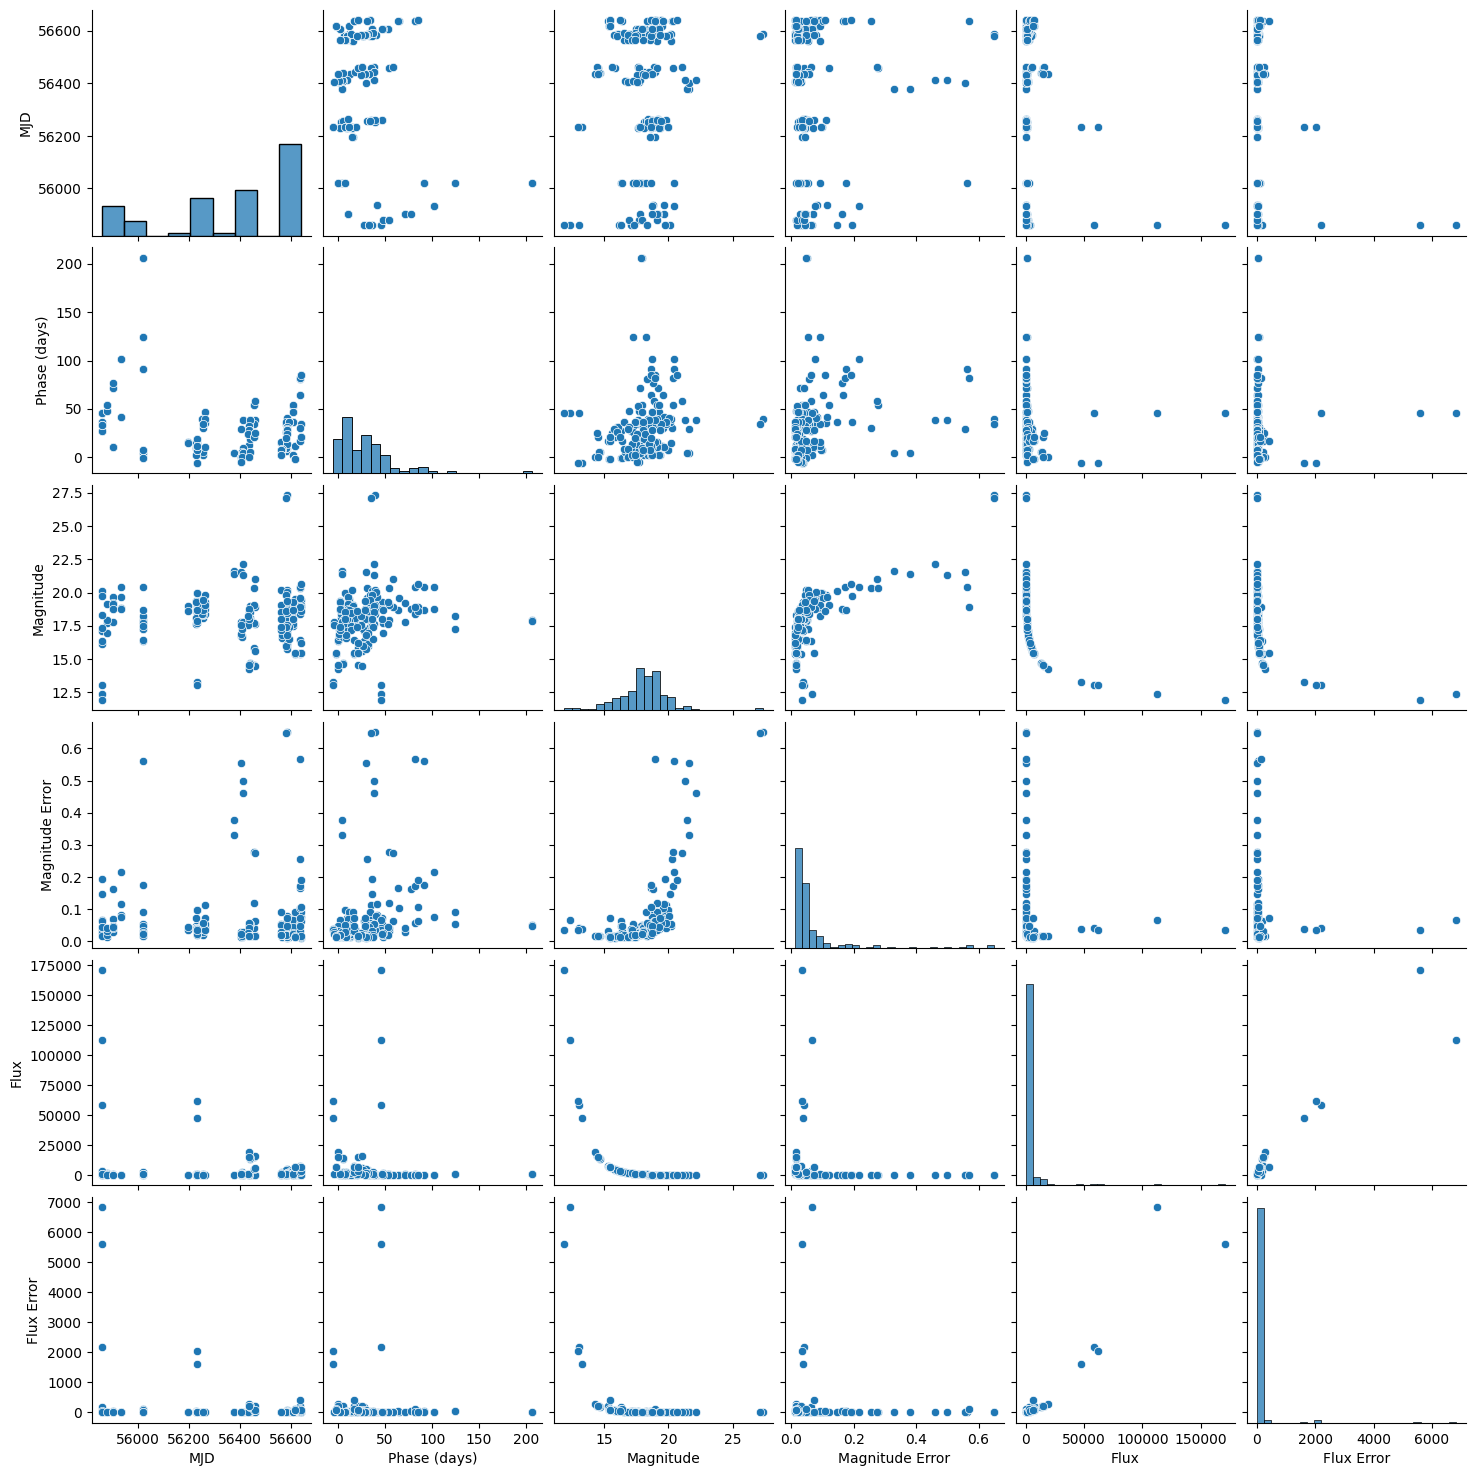

In [6]:
sb.pairplot(SweetSpot)

In [42]:
#need to find colors (J-H or H-J?) and error for colors (ugh) and then probably save that data file
# so for a given supernova, if there's another observation in a different band 
# find it, append it
# i want to make a copy of the data table first before I start fucking around


In [16]:
SweetSpot["Color (J-H)"] = np.nan
SweetSpot["Color Error"] = np.nan
SweetSpot["Delta T2"] = np.nan

In [17]:
for i in range(len(SweetSpot["Name"])):
    for j in range(len(SweetSpot["Name"])):
        if i != j and SweetSpot["Name"][i] == SweetSpot["Name"][j]:
            if np.abs(SweetSpot["MJD"][i]-SweetSpot["MJD"][j]) < 1:
                if SweetSpot["Filter"][i] == "WHIRCJ" and SweetSpot["Filter"][j] == "WHIRCH":
                    J_H = SweetSpot["Magnitude"][i] - SweetSpot["Magnitude"][j]
                    J_H_error = np.sqrt(SweetSpot["Magnitude Error"][i]**2+SweetSpot["Magnitude Error"][j]**2)
                    SweetSpot["Color (J-H)"][i] = J_H
                    SweetSpot["Color Error"][i] = J_H_error
                    SweetSpot["Delta T2"][i] = np.abs(SweetSpot["MJD"][i]-SweetSpot["MJD"][j])
                elif SweetSpot["Filter"][j] == "WHIRCJ" and SweetSpot["Filter"][i] == "WHIRCH":
                    J_H = SweetSpot["Magnitude"][j] - SweetSpot["Magnitude"][i]
                    J_H_error = np.sqrt(SweetSpot["Magnitude Error"][i]**2+SweetSpot["Magnitude Error"][j]**2)
                    SweetSpot["Color (J-H)"][i] = J_H
                    SweetSpot["Color Error"][i] = J_H_error
                    SweetSpot["Delta T2"][i] = np.abs(SweetSpot["MJD"][i]-SweetSpot["MJD"][j])
SweetSpot

/var/folders/j3/zxnzwfbx3p1b8vjdt5n_3l7c0000gn/T/ipykernel_45101/4149848419.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  SweetSpot["Color (J-H)"][i] = J_H
/var/folders/j3/zxnzwfbx3p1b8vjdt5n_3l7c0000gn/T/ipykernel_45101/4149848419.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  SweetSpot["Color Error"][i] = J_H_error
/var/folders/j3/zxnzwfbx3p1b8vjdt5n_3l7c0000gn/T/ipykernel_45101/4149848419.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-v

,Name,MJD,Phase (days),Filter,Magnitude,Magnitude Error,Flux,Flux Error,Color (J-H),Color Error,Delta T2
0,CSS121009:011101-172841,56234.27359,14.27359,WHIRCJ,18.97756,0.05157,256.4340,12.1698,0.43978,0.066270,0.04702
1,CSS121009:011101-172841,56229.31361,9.31361,WHIRCH,18.64361,0.04781,348.7850,15.3479,0.62963,0.085605,0.02820
2,CSS121009:011101-172841,56229.28541,9.28541,WHIRCJ,19.27324,0.07101,195.3014,12.7551,0.62963,0.085605,0.02820
3,CSS121009:011101-172841,56234.22657,14.22657,WHIRCH,18.53778,0.04162,384.4939,14.7330,0.43978,0.066270,0.04702
4,CSS121114:090202+101800,56254.50847,2.50847,WHIRCH,18.08766,0.02963,582.0156,15.8819,0.30975,0.036104,0.01634
...,...,...,...,...,...,...,...,...,...,...,...
181,iPTF13ebh,56640.15049,21.15049,WHIRCJ,16.22341,0.01276,3240.6910,38.0783,0.74854,0.017104,0.00954
182,iPTF13ebh,56617.15312,-1.84688,WHIRCK,15.39068,0.01739,6977.9267,111.7250,NaN,NaN,NaN
183,iPTF13ebh,56636.16017,17.16017,WHIRCK,15.48230,0.07114,6413.2790,419.6413,NaN,NaN,NaN
184,iPTF13ebh,56640.15936,21.15936,WHIRCK,15.45387,0.01509,6583.4459,91.4833,NaN,NaN,NaN


In [14]:
SweetSpot[SweetSpot["Name"] == "iPTF13ebh"]

,Name,MJD,Phase (days),Filter,Magnitude,Magnitude Error,Flux,Flux Error,Color (J-H),Color Error,Delta T2
177,iPTF13ebh,56636.14241,17.14241,WHIRCH,15.36282,0.03184,7159.3150,209.8877,1.05650,0.057400,0.00954
178,iPTF13ebh,56640.14095,21.14095,WHIRCH,15.47487,0.01139,6457.3185,67.7338,0.74854,0.017104,0.00954
179,iPTF13ebh,56617.14329,-1.85671,WHIRCJ,15.40729,0.01294,6871.9917,81.8816,-0.06578,0.018743,0.00954
180,iPTF13ebh,56636.15130,17.15130,WHIRCJ,16.41932,0.04776,2705.6447,118.9459,1.05650,0.057400,0.00954
181,iPTF13ebh,56640.15049,21.15049,WHIRCJ,16.22341,0.01276,3240.6910,38.0783,0.74854,0.017104,0.00954
182,iPTF13ebh,56617.15312,-1.84688,WHIRCK,15.39068,0.01739,6977.9267,111.7250,NaN,NaN,0.00954
183,iPTF13ebh,56636.16017,17.16017,WHIRCK,15.48230,0.07114,6413.2790,419.6413,NaN,NaN,0.00954
184,iPTF13ebh,56640.15936,21.15936,WHIRCK,15.45387,0.01509,6583.4459,91.4833,NaN,NaN,0.00954
185,iPTF13ebh,56617.13733,-1.86267,WHIRCH,15.47307,0.01356,6468.0416,80.7895,-0.06578,0.018743,0.00954


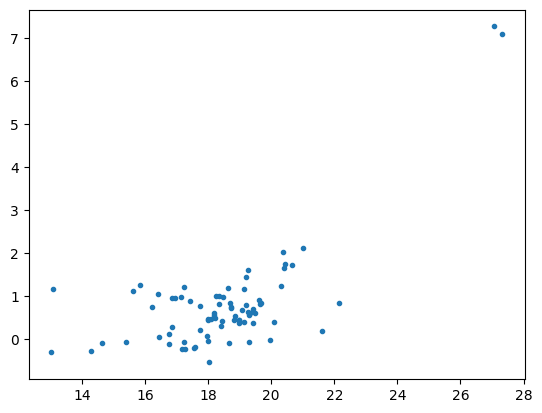

In [11]:
only_J = SweetSpot["Filter"]=="WHIRCJ"
plt.plot(SweetSpot["Magnitude"][only_J],SweetSpot["Color (J-H)"][only_J],".")

In [27]:
SweetSpot_plus = SweetSpot.copy()


Name                     loser
MJD                56229.28541
Phase (days)           9.28541
Filter                  WHIRCJ
Magnitude             19.27324
Magnitude Error        0.07101
Flux                  195.3014
Flux Error             12.7551
Color (J-H)            0.62963
Color Error           0.085605
Delta T2                0.0282
Name: 186, dtype: object


,Name,MJD,Phase (days),Filter,Magnitude,Magnitude Error,Flux,Flux Error,Color (J-H),Color Error,Delta T2
0,CSS121009:011101-172841,56234.27359,14.27359,WHIRCJ,18.97756,0.05157,256.4340,12.1698,0.43978,0.066270,0.04702
1,CSS121009:011101-172841,56229.31361,9.31361,WHIRCH,18.64361,0.04781,348.7850,15.3479,0.62963,0.085605,0.02820
2,CSS121009:011101-172841,56229.28541,9.28541,WHIRCJ,19.27324,0.07101,195.3014,12.7551,0.62963,0.085605,0.02820
3,CSS121009:011101-172841,56234.22657,14.22657,WHIRCH,18.53778,0.04162,384.4939,14.7330,0.43978,0.066270,0.04702
4,CSS121114:090202+101800,56254.50847,2.50847,WHIRCH,18.08766,0.02963,582.0156,15.8819,0.30975,0.036104,0.01634
...,...,...,...,...,...,...,...,...,...,...,...
182,iPTF13ebh,56617.15312,-1.84688,WHIRCK,15.39068,0.01739,6977.9267,111.7250,NaN,NaN,NaN
183,iPTF13ebh,56636.16017,17.16017,WHIRCK,15.48230,0.07114,6413.2790,419.6413,NaN,NaN,NaN
184,iPTF13ebh,56640.15936,21.15936,WHIRCK,15.45387,0.01509,6583.4459,91.4833,NaN,NaN,NaN
185,iPTF13ebh,56617.13733,-1.86267,WHIRCH,15.47307,0.01356,6468.0416,80.7895,-0.06578,0.018743,0.00596


In [28]:
#Next step is calculating magnitude change and time gaps
# I mean, I can do that now
SweetSpot_plus["Delta Magnitude"] = np.nan
SweetSpot_plus["Delta Magnitude Error"] = np.nan
SweetSpot_plus["Delta T1"] = np.nan

for i in range(len(SweetSpot["Name"])):
    it = 0
    for j in range(len(SweetSpot["Name"])):
        if i != j and (SweetSpot["Name"].iloc[i] == SweetSpot["Name"].iloc[j]) and (SweetSpot["Filter"].iloc[i]== SweetSpot["Filter"].iloc[j]):
            if SweetSpot["MJD"].iloc[i]-SweetSpot["MJD"].iloc[j] > 0:
                if it == 0:
                    SweetSpot_plus["Delta Magnitude"].iloc[i] = SweetSpot["Magnitude"].iloc[i]-SweetSpot["Magnitude"].iloc[j]
                    SweetSpot_plus["Delta Magnitude Error"].iloc[i] = np.sqrt(SweetSpot["Magnitude Error"].iloc[i]**2+SweetSpot["Magnitude Error"].iloc[j]**2)
                    SweetSpot_plus["Delta T1"].iloc[i] = SweetSpot["MJD"].iloc[i]-SweetSpot["MJD"].iloc[j]
                else:
                    end = len(SweetSpot_plus)
                    SweetSpot_plus.loc[end] = SweetSpot.loc[i]
                    SweetSpot_plus.loc[end, "Delta Magnitude"] = SweetSpot["Magnitude"].iloc[i]-SweetSpot["Magnitude"].iloc[j]
                    SweetSpot_plus.loc[end, "Delta Magnitude Error"] = np.sqrt(SweetSpot["Magnitude Error"].iloc[i]**2+SweetSpot["Magnitude Error"].iloc[j]**2)
                    SweetSpot_plus.loc[end, "Delta T1"] = SweetSpot["MJD"].iloc[i]-SweetSpot["MJD"].iloc[j]
                it += 1

SweetSpot_plus

/var/folders/j3/zxnzwfbx3p1b8vjdt5n_3l7c0000gn/T/ipykernel_45101/4292105749.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  SweetSpot_plus["Delta Magnitude"].iloc[i] = SweetSpot["Magnitude"].iloc[i]-SweetSpot["Magnitude"].iloc[j]
/var/folders/j3/zxnzwfbx3p1b8vjdt5n_3l7c0000gn/T/ipykernel_45101/4292105749.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  SweetSpot_plus["Delta Magnitude Error"].iloc[i] = np.sqrt(SweetSpot["Magnitude Error"].iloc[i]**2+SweetSpot["Magnitude Error"].iloc[j]**2)
/var/folders/j3/zxnzwfbx3p1b8vjdt5n_3l7c0000gn/T/ipykernel_45101/4292105749.py:15: SettingWithCopyWarning: 
A value is tryi

,Name,MJD,Phase (days),Filter,Magnitude,Magnitude Error,Flux,Flux Error,Color (J-H),Color Error,Delta T2,Delta Magnitude,Delta Magnitude Error,Delta T1
0,CSS121009:011101-172841,56234.27359,14.27359,WHIRCJ,18.97756,0.05157,256.4340,12.1698,0.43978,0.066270,0.04702,-0.29568,0.087760,4.98818
1,CSS121009:011101-172841,56229.31361,9.31361,WHIRCH,18.64361,0.04781,348.7850,15.3479,0.62963,0.085605,0.02820,NaN,NaN,NaN
2,CSS121009:011101-172841,56229.28541,9.28541,WHIRCJ,19.27324,0.07101,195.3014,12.7551,0.62963,0.085605,0.02820,NaN,NaN,NaN
3,CSS121009:011101-172841,56234.22657,14.22657,WHIRCH,18.53778,0.04162,384.4939,14.7330,0.43978,0.066270,0.04702,-0.10583,0.063388,4.91296
4,CSS121114:090202+101800,56254.50847,2.50847,WHIRCH,18.08766,0.02963,582.0156,15.8819,0.30975,0.036104,0.01634,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,iPTF13dkx,56608.15223,47.15223,WHIRCH,17.97829,0.02146,643.7012,12.7196,0.74376,0.033875,0.01198,0.53217,0.028392,26.91324
318,iPTF13dkx,56608.15223,47.15223,WHIRCH,17.97829,0.02146,643.7012,12.7196,0.74376,0.033875,0.01198,0.58868,0.029719,44.73900
319,iPTF13ebh,56640.14095,21.14095,WHIRCH,15.47487,0.01139,6457.3185,67.7338,0.74854,0.017104,0.00954,0.00180,0.017709,23.00362
320,iPTF13ebh,56640.15049,21.15049,WHIRCJ,16.22341,0.01276,3240.6910,38.0783,0.74854,0.017104,0.00954,-0.19591,0.049435,3.99919


In [ ]:
# okay leaving this here, but when I return, I'll figure out how to get this to work properly
# data wrangling is annoying
# I'll also convert the 
# could also find H-K and J-K colors in the case that K observations do exist

I used the light curve data from the first data release of SweetSpot. I calculated the J-H color where possible and propogated the error from the magnitude. I also added the time interval between observations for the color, but that was kind of pointless because it was the same time interval for all observations between the different filters. I also calculated the change in magnitude between observations and recorded the time interval between observations in the same pass-band.

(array([10., 48.,  3.,  7.,  6.,  3.,  0.,  0.,  5.,  4.,  6., 20.,  9.,
        23.,  7., 11., 16.,  1., 10.,  7.,  2.,  0.,  2.,  0.,  0.,  0.,
         5.,  6.,  0.,  6.,  3.,  5.,  9.,  3.,  3.,  5.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  2.,  2.,  0.,  2.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  2.]),
 array([  1.98635  ,   3.5706632,   5.1549764,   6.7392896,   8.3236028,
          9.907916 ,  11.4922292,  13.0765424,  14.6608556,  16.2451688,
         17.829482 ,  19.4137952,  20.9981084,  22.5824216,  24.1667348,
         25.751048 ,  27.3353612,  28.9196744,  30.5039876,  32.0883008,
         33.672614 ,  35.2569272,  36.8412404,  38.4255536,  40.0098668,
         41.59418  ,  43.1784932,  44.7628064,  46.3471196,  47.93143

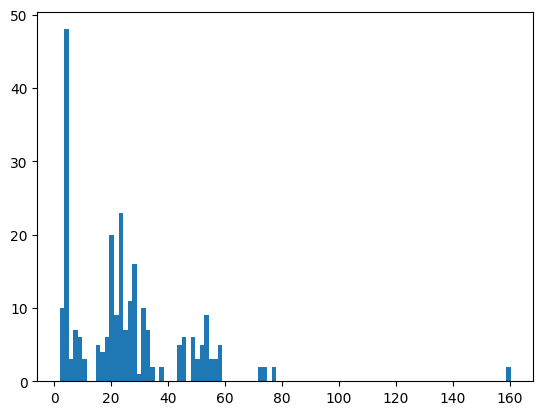

In [31]:
plt.hist(SweetSpot_plus["Delta T1"],bins = 100)

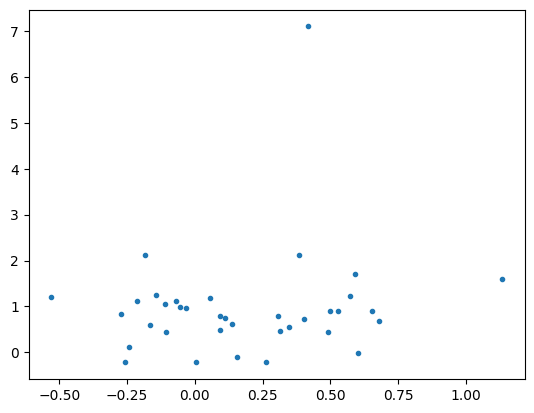

In [41]:
only_J = SweetSpot_plus["Filter"]=="WHIRCH"
T_about_5 = (SweetSpot_plus["Delta T1"] > 3) & (SweetSpot_plus["Delta T1"] <= 20)
plt.plot(SweetSpot_plus["Delta Magnitude"][only_J][T_about_5],SweetSpot_plus["Color (J-H)"][only_J][T_about_5],".")

Wow I look at that and all I can think is... seems absolutely useless.
But the good news is that I now understand this space a little bit more and I'll take it.